In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Kütüphaneler yüklendi")


✅ Kütüphaneler yüklendi


In [4]:
df = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')

print("Toplam satır:", len(df))
print("Kolon sayısı:", len(df.columns))
print()
print("Sınıf Dağılımı:")
print(df['label'].value_counts())

Toplam satır: 235795
Kolon sayısı: 56

Sınıf Dağılımı:
label
1    134850
0    100945
Name: count, dtype: int64


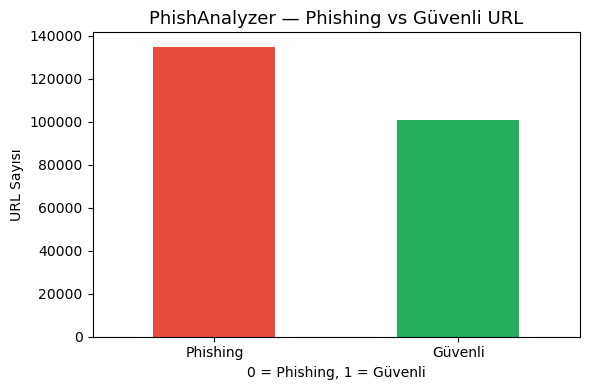

✅ Grafik kaydedildi


In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
df['label'].value_counts().plot(
    kind='bar',
    color=['#E74C3C', '#27AE60'],
    ax=ax
)
ax.set_title('PhishAnalyzer — Phishing vs Güvenli URL', fontsize=13)
ax.set_xlabel('0 = Phishing, 1 = Güvenli')
ax.set_ylabel('URL Sayısı')
ax.set_xticklabels(['Phishing', 'Güvenli'], rotation=0)
plt.tight_layout()
plt.savefig('dagilim.png', dpi=150)
plt.show()
print("✅ Grafik kaydedildi")

In [6]:
features = [
    'URLLength', 'IsHTTPS', 'NoOfSubDomain', 'IsDomainIP',
    'URLSimilarityIndex', 'TLDLegitimateProb', 'HasObfuscation',
    'NoOfObfuscatedChar', 'HasPasswordField', 'Bank', 'Pay',
    'Crypto', 'DegitRatioInURL', 'NoOfAmpersandInURL',
    'DomainTitleMatchScore', 'URLTitleMatchScore'
]

X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim seti:", len(X_train), "satır")
print("Test seti:", len(X_test), "satır")

Eğitim seti: 188636 satır
Test seti: 47159 satır


In [7]:
modeller = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42),
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', random_state=42, max_iter=1000),
    "XGBoost": XGBClassifier(
        random_state=42, eval_metric='logloss')
}

sonuclar = {}
for isim, model in modeller.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    sonuclar[isim] = acc
    print(f"{isim}: %{acc*100:.2f}")

en_iyi = max(sonuclar, key=sonuclar.get)
print()
print(f"🏆 En iyi model: {en_iyi} — %{sonuclar[en_iyi]*100:.2f}")


Random Forest: %99.99
Logistic Regression: %99.98
XGBoost: %99.99

🏆 En iyi model: Random Forest — %99.99


In [8]:
best_model = modeller[en_iyi]

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred,
      target_names=['Phishing', 'Güvenli']))

joblib.dump(best_model, 'phishanalyzer_model.pkl')
joblib.dump(features, 'phishanalyzer_features.pkl')
print("✅ Model kaydedildi: phishanalyzer_model.pkl")

              precision    recall  f1-score   support

    Phishing       1.00      1.00      1.00     20124
     Güvenli       1.00      1.00      1.00     27035

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

✅ Model kaydedildi: phishanalyzer_model.pkl


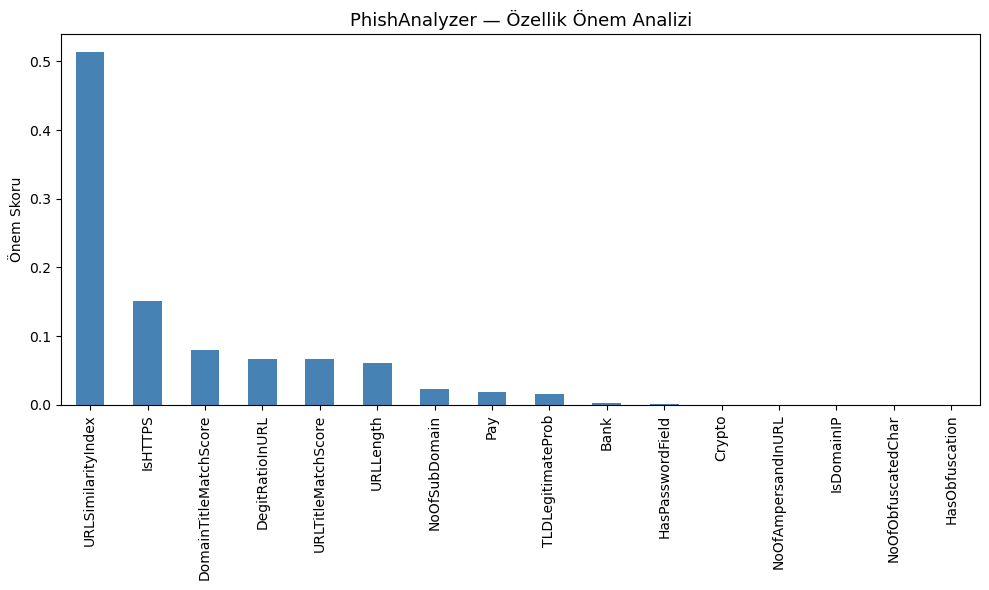

✅ Feature importance grafiği kaydedildi


In [9]:
rf_model = modeller["Random Forest"]

importances = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue')
plt.title('PhishAnalyzer — Özellik Önem Analizi', fontsize=13)
plt.ylabel('Önem Skoru')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance grafiği kaydedildi")

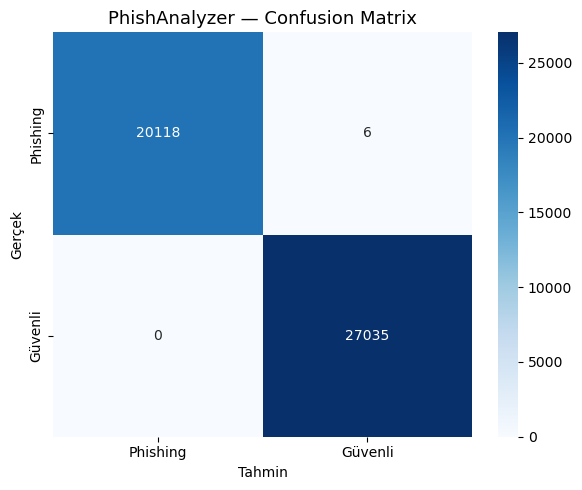

✅ Confusion matrix kaydedildi


In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Phishing', 'Güvenli'],
            yticklabels=['Phishing', 'Güvenli'])
plt.title('PhishAnalyzer — Confusion Matrix', fontsize=13)
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix kaydedildi")